# Isolation Forest


## Goal

This notebook implements an **Early Warning System (EWS)** designed to detect periods of financial market stress and potential crises. The objective is to identify abnormal market regimes as early as possible.
The first part of the notebook uses **Isolation Forest**, a widely used anomaly detection algorithm based on the idea that abnormal observations are easier to isolate than normal ones. By recursively partitioning the feature space, the algorithm assigns an anomaly score to each observation: market periods that are isolated in fewer splits are considered more unusual and may correspond to financial stress episodes.

In a second step, the notebook extends this approach with an **Isolation Mondrian Forest**. Mondrian forests are based on random recursive partitions that can be updated efficiently and naturally handle sequential data. This makes them particularly relevant for financial time series, where new observations arrive over time and market conditions evolve continuously. Compared with a standard Isolation Forest, the Mondrian-based approach is better suited to an online or dynamic setting, allowing the model to adapt more flexibly to changing market regimes while preserving the core intuition of anomaly detection through isolation.

### Notebook structure: 

1. Import of libraries
2. Loading and exploration of Bloomberg data
3. Feature engineering (weekly yields)
4. Split training / validation / testing
5. Remove redundant features
6. Standardization
7. Anomaly detection with Isolation Forest
8. Evaluation (Precision, Recall, F2, ROC, Confusion Matrix)
9. Temporal visualization of the anomaly score
10. PCA projection of results
11. Analysis of feature importance (permutation importance)

<br>

## 1. Import of libraries

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_score, recall_score, fbeta_score,
    confusion_matrix, roc_curve, auc, f1_score, 
    roc_auc_score, classification_report
)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

## 2. Loading and exploration of Bloomberg data

The Bloomberg dataset contains weekly data on:

- Equity indices (MSCI USA, Europe, Japan, EM...)
- Bond indices (IG, HY, Inflation-linked, MBS...)
- Interest rates (US, Germany, UK, Japan, Italy)
- Currencies (USD, GBP, JPY)
- Commodities (oil, gold, CRB)
- Leading indicators (VIX, Baltic Dry Index, Economic Surprise)

A `label` column indicates **abnormal** weeks (risk-off = 1) vs. **normal** weeks (risk-on = 0).

In [122]:
DATA_PATH = "Dataset4_EWS.xlsx"

df_raw = pd.read_excel(DATA_PATH, index_col=0, parse_dates=True)
df_raw.index.name = "Date"
df_raw = df_raw.sort_index()

print(f"Shape : {df_raw.shape}")
print(f"Période from : {df_raw.index.min().date()} to {df_raw.index.max().date()}")
print(f"\nColonnes ({len(df_raw.columns)}) :")
df_raw.head(10)

Shape : (1111, 43)
Période from : 2000-01-11 to 2021-04-20

Colonnes (43) :


,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL,Y
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25,0
2000-01-18,1405,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65,0
2000-01-25,1368,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15,0
2000-02-01,1311,166.85,28.22,104.92,0.191,231.9417,3.30,1.6106,6.619,5.459,...,1007.12,201.89,1385.31,5.88500,6.574,6.423,5.708,23.45,282.75,0
2000-02-08,1277,165.43,28.02,104.22,0.312,237.8117,3.26,1.6108,6.613,5.482,...,1034.58,218.00,1411.95,5.89125,6.678,6.231,5.677,21.25,298.40,1
2000-02-15,1393,169.58,30.06,104.69,0.391,240.1163,3.25,1.5966,6.552,5.562,...,1007.86,204.59,1369.47,5.88000,6.628,6.246,5.740,22.92,303.90,1
2000-02-22,1481,168.86,29.62,103.28,0.497,240.1438,3.20,1.6166,6.361,5.415,...,987.38,206.14,1315.93,5.88000,6.551,6.086,5.764,25.86,305.50,1
2000-02-29,1531,170.20,30.43,105.92,0.497,243.1049,3.34,1.5802,6.409,5.500,...,1014.69,199.23,1333.28,5.91250,6.521,6.140,5.781,23.37,293.30,1
2000-03-07,1602,179.94,34.13,106.01,0.484,246.5223,3.28,1.5756,6.373,5.432,...,994.72,234.18,1319.95,5.95000,6.486,6.145,5.834,24.31,292.00,0


In [123]:
# Overall statistics
df_raw.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
BDIY,1111.0,2259.860,2017.812,291.000,990.000,1518.000,2685.500,11793.000
CRY,1111.0,245.248,68.278,106.293,184.706,234.560,301.539,467.570
Cl1,1111.0,60.708,25.901,10.010,39.625,57.400,79.640,140.970
DXY,1111.0,90.935,11.379,71.329,81.240,89.716,97.404,119.820
ECSURPUS,1111.0,0.036,0.349,-0.974,-0.191,0.035,0.260,0.991
EMUSTRUU,1111.0,704.379,309.952,230.527,434.661,714.807,939.825,1286.353
EONIA,1111.0,1.364,1.722,-0.498,-0.230,0.437,2.890,5.730
GBP,1111.0,1.570,0.212,1.172,1.418,1.562,1.677,2.085
GT10,1111.0,3.267,1.332,0.508,2.196,3.115,4.345,6.748
GTDEM10Y,1111.0,2.448,1.852,-0.794,0.539,2.994,4.080,5.644


### Checking for missing values:

In [125]:
missing = df_raw.isnull().sum()
print("Missing values per column :")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

Missing values per column :
No missing values


### Analysis of dependent variables: 

distribution of dependent variables :
Y
0    874
1    237
Name: count, dtype: int64

Anomaly rate : 21.33%


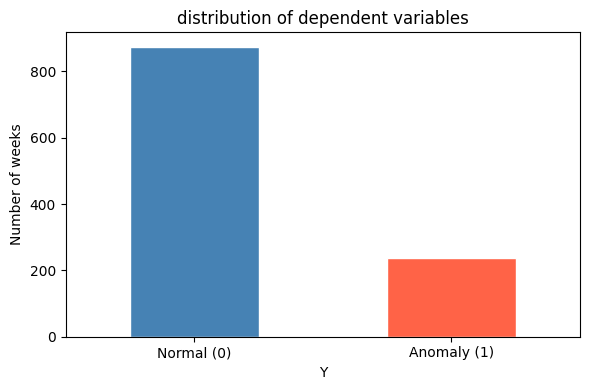

In [126]:
LABEL_COL = "Y"

label_counts = df_raw[LABEL_COL].value_counts().sort_index()
print("distribution of dependent variables :")
print(label_counts)
print(f"\nAnomaly rate : {label_counts.get(1, 0) / len(df_raw):.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
ax.set_xticklabels(["Normal (0)", "Anomaly (1)"], rotation=0)
ax.set_title("distribution of dependent variables")
ax.set_ylabel("Number of weeks")
plt.tight_layout()
plt.show()

### Temporal visualization of the label:

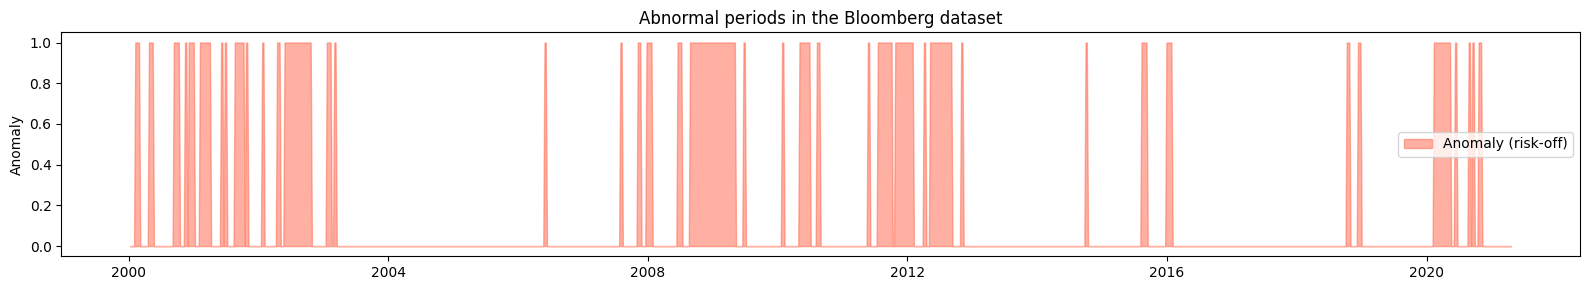

In [127]:
fig, ax = plt.subplots(figsize=(16, 3))
ax.fill_between(
    df_raw.index,
    df_raw[LABEL_COL],
    alpha=0.5,
    color="tomato",
    label="Anomaly (risk-off)"
)
ax.set_title("Abnormal periods in the Bloomberg dataset")
ax.set_ylabel("Anomaly")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Raw price series are generally non-stationary, which makes them less suitable for machine learning models. To obtain more stable and stationary features, we compute **weekly log-returns** for price-based assets:

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$

For interest rates and spreads, log-returns are not appropriate because these variables are already expressed in levels or percentage points. Therefore, we use **simple differences**:

$$\Delta X_t = X_t - X_{t-1}$$

Finally, some indicators such as the Economic Surprise Index can be kept in levels, depending on their interpretation, since they already reflect changes in macroeconomic conditions.


In [128]:
feature_cols = [col for col in df_raw.columns if col != LABEL_COL]

RATE_COLS = [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]

LEVEL_COLS = ["ECSURPUS"]

PRICE_COLS = [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]

print(f"Log-return columns  ({len(PRICE_COLS)}) :  {PRICE_COLS}")
print("\n")
print(f"Simple difference columns ({len(RATE_COLS)})  :  {RATE_COLS}")
print("\n")
print(f"Columns not modified ({len(LEVEL_COLS)})  :  {LEVEL_COLS}")

Log-return columns  (23) :  ['XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX']


Simple difference columns (18)  :  ['EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR']


Columns not modified (1)  :  ['ECSURPUS']


In [129]:
returns_prices = np.log(df_raw[PRICE_COLS] / df_raw[PRICE_COLS].shift(1))

returns_rates = df_raw[RATE_COLS].diff()

returns_levels = df_raw[LEVEL_COLS].copy()

returns_df_base = pd.concat(
    [
        returns_prices,
        returns_rates,
        returns_levels,
    ],
    axis=1
)

### Distribution of yields for some key features :

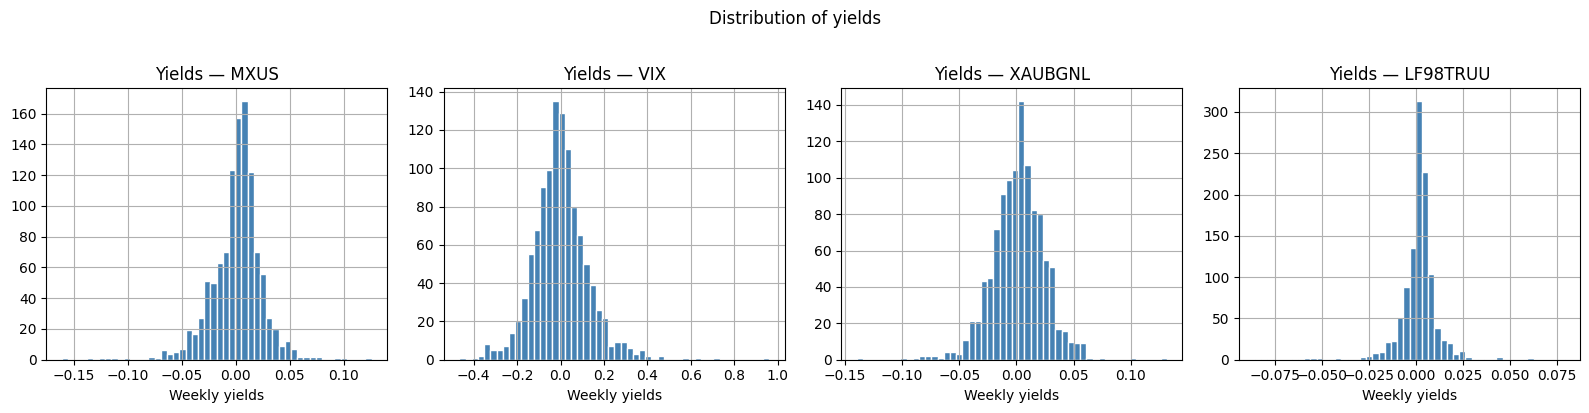

In [130]:
KEY_FEATURES = ["MXUS", "VIX", "XAUBGNL", "LF98TRUU"]
key_features_available = [f for f in KEY_FEATURES if f in returns_df_base.columns]

if key_features_available:
    fig, axes = plt.subplots(1, len(key_features_available), figsize=(16, 4))
    for ax, col in zip(axes, key_features_available):
        returns_df_base[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
        ax.set_title(f"Yields — {col}")
        ax.set_xlabel("Weekly yields")
    plt.suptitle("Distribution of yields", y=1.02)
    plt.tight_layout()
    plt.show()

In this step, we enrich the dataset by creating additional financial indicators from the transformed series. The goal is to give the model more information about market dynamics than simple returns alone.

For price-based assets, we compute rolling volatility, momentum, and drawdown over different time windows. These features help capture changes in risk, trend direction, and cumulative losses. For interest rates and macro-level variables, we add lagged differences and rolling volatility to measure recent changes in their levels.

We also include VIX-specific features, since the VIX is a key indicator of market stress, and rolling correlations with the US equity index to capture changes in market co-movements.

Overall, these engineered features are designed to help the Early Warning System better identify abnormal market regimes and potential crisis periods.


In [131]:
engineered_blocks = []

# Volatility, momentum and drawdown for price series
for col in PRICE_COLS:
    if col in df_raw.columns:
        ret = returns_prices[col]

        block = pd.DataFrame({
            f"{col}_vol_4w": ret.rolling(4).std(),
            f"{col}_vol_12w": ret.rolling(12).std(),
            f"{col}_vol_26w": ret.rolling(26).std(),

            f"{col}_mom_4w": ret.rolling(4).sum(),
            f"{col}_mom_12w": ret.rolling(12).sum(),
            f"{col}_mom_26w": ret.rolling(26).sum(),

            f"{col}_drawdown_26w": df_raw[col] / df_raw[col].rolling(26).max() - 1,
            f"{col}_drawdown_52w": df_raw[col] / df_raw[col].rolling(52).max() - 1,
        }, index=df_raw.index)

        engineered_blocks.append(block)

# Additional rate features
for col in RATE_COLS:
    if col in df_raw.columns:
        block = pd.DataFrame({
            f"{col}_diff_4w": df_raw[col].diff(4),
            f"{col}_diff_12w": df_raw[col].diff(12),
        }, index=df_raw.index)

        engineered_blocks.append(block)

# Additional level features
for col in LEVEL_COLS:
    if col in df_raw.columns:
        block = pd.DataFrame({
            f"{col}_level_diff_1w": df_raw[col].diff(),
            f"{col}_level_diff_4w": df_raw[col].diff(4),
            f"{col}_level_diff_12w": df_raw[col].diff(12),
            f"{col}_level_vol_4w": df_raw[col].rolling(4).std(),
            f"{col}_level_vol_12w": df_raw[col].rolling(12).std(),
        }, index=df_raw.index)

        engineered_blocks.append(block)

# VIX-specific features
if "VIX" in df_raw.columns:
    vix_block = pd.DataFrame({
        "VIX_change_4w": df_raw["VIX"].diff(4),
        "VIX_change_12w": df_raw["VIX"].diff(12),
        "VIX_vol_4w": df_raw["VIX"].rolling(4).std(),
        "VIX_vol_12w": df_raw["VIX"].rolling(12).std(),
    }, index=df_raw.index)

    engineered_blocks.append(vix_block)

# Rolling correlations with MXUS
REFERENCE_INDEX = "MXUS"

if REFERENCE_INDEX in PRICE_COLS and REFERENCE_INDEX in df_raw.columns:
    ref_ret = returns_prices[REFERENCE_INDEX]

    corr_blocks = []

    for col in PRICE_COLS:
        if col in df_raw.columns and col != REFERENCE_INDEX:
            asset_ret = returns_prices[col]

            corr_block = pd.DataFrame({
                f"{col}_corr_{REFERENCE_INDEX}_12w": asset_ret.rolling(12).corr(ref_ret),
                f"{col}_corr_{REFERENCE_INDEX}_26w": asset_ret.rolling(26).corr(ref_ret),
            }, index=df_raw.index)

            corr_blocks.append(corr_block)

    if len(corr_blocks) > 0:
        engineered_blocks.extend(corr_blocks)


if len(engineered_blocks) > 0:
    engineered_features = pd.concat(engineered_blocks, axis=1)
else:
    engineered_features = pd.DataFrame(index=df_raw.index)

returns_df = pd.concat(
    [
        returns_df_global,
        engineered_features
    ],
    axis=1
)

returns_df[LABEL_COL] = df_raw[LABEL_COL]

returns_df = returns_df.replace([np.inf, -np.inf], np.nan)
returns_df = returns_df.dropna().copy()

feature_cols = [col for col in returns_df.columns if col != LABEL_COL]

n_inf = np.isinf(returns_df[feature_cols].to_numpy()).sum()
n_nan = np.isnan(returns_df[feature_cols].to_numpy()).sum()

print("returns_df shape:", returns_df.shape)
print("Number of features:", len(feature_cols))
print(f"Valeurs inf : {n_inf}")
print(f"Valeurs NaN : {n_nan}")

print("\nFirst 20 features:")
print(feature_cols[:20])

returns_df shape: (1060, 316)
Number of features: 315
Valeurs inf : 0
Valeurs NaN : 0

First 20 features:
['XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP']


## 4. Train / Validation / Test Split

- **Train** (70%)
- **Validation** (15%)
- **Test** (15%)

We use Isolation Forest in a semi-supervised novelty detection setting: the model is fitted only on normal observations from the training set, and then used to detect deviations from normal market conditions.

Full training set :   742 weeks  (179 anomalies)
Normal training set:   563 weeks  (inliers only)
Validation set    :   159 weeks  (10 anomalies)
Test set          :   159 weeks  (29 anomalies)


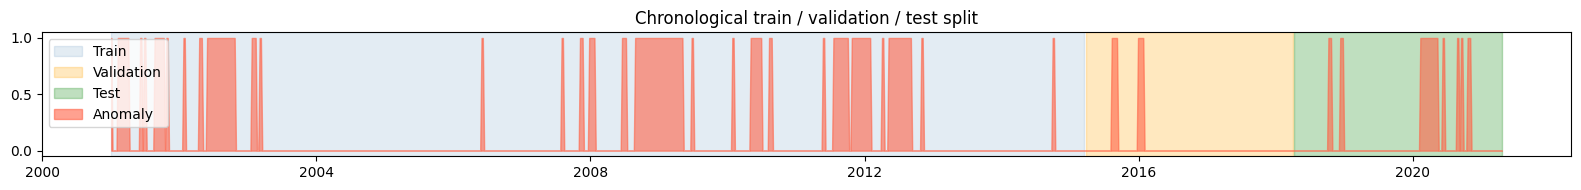

In [132]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# TEST_RATIO = 0.15, remaining part of the dataset

n = len(returns_df)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

# Chronological split
df_train_full = returns_df.iloc[:n_train]
df_val = returns_df.iloc[n_train:n_train + n_val]
df_test = returns_df.iloc[n_train + n_val:]

# Features and labels
X_train_full = df_train_full[feature_cols]
y_train_full = df_train_full[LABEL_COL]

X_val = df_val[feature_cols]
y_val = df_val[LABEL_COL]

X_test = df_test[feature_cols]
y_test = df_test[LABEL_COL]

# For unsupervised training: keep only normal observations
X_train_normal = X_train_full[y_train_full == 0]

print(f"Full training set : {len(X_train_full):>5} weeks  ({y_train_full.sum()} anomalies)")
print(f"Normal training set: {len(X_train_normal):>5} weeks  (inliers only)")
print(f"Validation set    : {len(X_val):>5} weeks  ({y_val.sum()} anomalies)")
print(f"Test set          : {len(X_test):>5} weeks  ({y_test.sum()} anomalies)")

# Split visualization
fig, ax = plt.subplots(figsize=(16, 2))

ax.axvspan(
    df_train_full.index[0],
    df_train_full.index[-1],
    alpha=0.15,
    color="steelblue",
    label="Train"
)

ax.axvspan(
    df_val.index[0],
    df_val.index[-1],
    alpha=0.25,
    color="orange",
    label="Validation"
)

ax.axvspan(
    df_test.index[0],
    df_test.index[-1],
    alpha=0.25,
    color="green",
    label="Test"
)

ax.fill_between(
    returns_df.index,
    returns_df[LABEL_COL],
    color="tomato",
    alpha=0.6,
    label="Anomaly"
)

ax.set_title("Chronological train / validation / test split")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 5. Remove redundant features

### Remove the near-constant features :

Now, let's proceed with the feature selection based solely on the training set. The idea is to avoid data leakage: if we also use the validation set or the test set to decide which features to keep, then we are indirectly giving the model information about the future.

In [133]:
selector = VarianceThreshold(threshold=1e-5)

# Fit only on the training set to avoid data leakage
selector.fit(X_train_full[feature_cols])

# Boolean mask: True = kept, False = removed
mask_variance = selector.get_support()

# Selected and removed features
feature_cols_filtered = [
    feature for feature, keep in zip(feature_cols, mask_variance) if keep
]

removed_low_variance_features = [
    feature for feature, keep in zip(feature_cols, mask_variance) if not keep
]

print(f"Features after variance filtering: {len(feature_cols_filtered)} / {len(feature_cols)}")
print(f"Removed low-variance features: {len(removed_low_variance_features)}")

print("\nList of removed low-variance features:")
for feature in removed_low_variance_features:
    print(f"- {feature}")

Features after variance filtering: 309 / 315
Removed low-variance features: 6

List of removed low-variance features:
- LMBITR_vol_26w
- LUACTRUU_vol_12w
- LUACTRUU_vol_26w
- LUMSTRUU_vol_4w
- LUMSTRUU_vol_12w
- LUMSTRUU_vol_26w


### Remove features that are too closely correlated with each other :

In [134]:
# Correlation matrix computed only on the filtered training features
corr_matrix = X_train_full[feature_cols_filtered].corr().abs()

# Keep only the upper triangle of the correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features to remove because they are highly correlated with another feature
removed_correlated_features = [
    col for col in upper.columns 
    if any(upper[col] > 0.95)
]

# Final feature list after variance and correlation filtering
feature_cols_decorr = [
    feature for feature in feature_cols_filtered 
    if feature not in removed_correlated_features
]

print(f"\nFeatures after decorrelation: {len(feature_cols_decorr)} / {len(feature_cols_filtered)}")
print(f"Removed highly correlated features: {len(removed_correlated_features)}")

print("\nList of removed highly correlated features:")
for feature in removed_correlated_features:
    print(f"- {feature}")


Features after decorrelation: 291 / 309
Removed highly correlated features: 30

List of removed highly correlated features:
- GTGBP30Y
- EMUSTRUU_drawdown_52w
- LG30TRUU_vol_12w
- LG30TRUU_vol_26w
- LG30TRUU_mom_4w
- LG30TRUU_mom_12w
- LG30TRUU_mom_26w
- LG30TRUU_drawdown_26w
- LG30TRUU_drawdown_52w
- LMBITR_drawdown_52w
- LUACTRUU_drawdown_52w
- LUMSTRUU_drawdown_52w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_12w
- VIX_vol_12w
- VIX_vol_12w
- VIX_vol_12w
- GTGBP30Y_diff_4w
- GTGBP30Y_diff_12w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_12w
- VIX_vol_12w
- VIX_vol_12w
- VIX_vol_12w


In [135]:
X_train_full = X_train_full[feature_cols_decorr].copy()
X_val = X_val[feature_cols_decorr].copy()
X_test = X_test[feature_cols_decorr].copy()

X_train_normal = X_train_full[y_train_full == 0].copy()

# Update the final feature list
feature_cols = feature_cols_decorr

print("\nFinal datasets after feature selection:")
print(f"X_train_full shape : {X_train_full.shape}")
print(f"X_train_normal shape: {X_train_normal.shape}")
print(f"X_val shape        : {X_val.shape}")
print(f"X_test shape       : {X_test.shape}")


Final datasets after feature selection:
X_train_full shape : (742, 291)
X_train_normal shape: (563, 291)
X_val shape        : (159, 291)
X_test shape       : (159, 291)


## 6. Standardisation

The Isolation Forest is theoretically not very sensitive to scale (it makes random cuts), but standardization improves numerical stability and facilitates comparisons between features.

In [136]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_train_full_scaled = scaler.transform(X_train_full)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train_normal.index)
X_train_full_scaled_df = pd.DataFrame(X_train_full_scaled, columns=feature_cols, index=X_train_full.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print(f"X_train_scaled (normal) : {X_train_scaled.shape}")
print(f"X_val_scaled : {X_val_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")

X_train_scaled (normal) : (563, 291)
X_val_scaled : (159, 291)
X_test_scaled : (159, 291)


## 7. Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm based on a simple intuition: anomalous observations are easier to isolate than normal ones.

The algorithm builds several random isolation trees. At each split, it randomly selects a feature and a split value within its range. This process is repeated until each observation is isolated. The key signal is the average path length needed to isolate a point:

* a short path length means that the observation is isolated quickly and is therefore more suspicious;
* a long path length means that the observation is harder to isolate and is more likely to be normal.

The `decision_function` returns an anomaly score. In this notebook, lower scores indicate more abnormal market conditions.

To convert anomaly scores into crisis alerts, we do not rely directly on the `contamination` parameter. Instead, we tune the decision threshold using the validation set. Several hyperparameter combinations are tested, including the number of trees, the maximum sample size, and the percentile used to define the anomaly threshold. The best configuration is selected according to validation performance, with a particular focus on recall and F2-score, since missing a crisis is more costly than generating a few false alerts.

Once the best hyperparameters and threshold have been selected on the validation set, the final performance is evaluated only once on the test set. This ensures a more realistic assessment of the Early Warning System on unseen data.


### Key hyperparameters

| Parameter | Role |
|---|---|
| `n_estimators` | Number of isolation trees. A larger value generally improves stability. |
| `max_samples` | Number of observations sampled to build each tree. `"auto"` uses `min(256, n_samples)`. |
| `score_percentile` | Percentile of validation anomaly scores used to define the alert threshold. |
| `contamination` | Not directly used here, since the threshold is tuned manually on the validation set. |
| `random_state` | Ensures reproducibility of the results. |

### To begin, we test a simple isolate forest algorithm with a percentile score of 5%.

In [137]:
def run_isolation_forest_percentile(
    X_train_scaled, X_train_full_scaled, X_val_scaled, X_test_scaled,
    X_train_full, X_val, X_test,
    score_percentile: float = 5.0,
    n_estimators: int = 600,
    max_samples="auto",
    random_state: int = 42
):

    iso = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        random_state=random_state
    )
    iso.fit(X_train_scaled)

    scores_train = iso.decision_function(X_train_full_scaled)
    scores_val = iso.decision_function(X_val_scaled)
    scores_test = iso.decision_function(X_test_scaled)

    scores_train_s = pd.Series(scores_train, index=X_train_full.index, name="AnomalyScore")
    scores_val_s = pd.Series(scores_val,   index=X_val.index, name="AnomalyScore")
    scores_test_s = pd.Series(scores_test,  index=X_test.index, name="AnomalyScore")

    # Threshold calibration on the validation set
    score_threshold = np.percentile(scores_val, score_percentile)

    y_pred_val  = (scores_val  <= score_threshold).astype(int)
    y_pred_test = (scores_test <= score_threshold).astype(int)

    print(f" Percentile ({score_percentile}%)")
    print(f"Average score train: {scores_train.mean():.4f}")
    print(f"Average score val: {scores_val.mean():.4f}")
    print(f"Average score test: {scores_test.mean():.4f}")
    print(f"Threshold ({score_percentile}% percentile on validation set): {score_threshold:.6f}")
    print(f"Validation predictions: {y_pred_val.sum()} anomalies / {len(y_pred_val)} weeks")
    print(f"Test predictions: {y_pred_test.sum()} anomalies / {len(y_pred_test)} weeks")

    return iso, score_threshold, scores_val_s, scores_test_s, scores_train_s, y_pred_val, y_pred_test

## 7. Model evaluation

In an Early Warning System, the key evaluation metrics are:

- Recall or sensitivity: avoiding missed crises is the main priority.
- Precision: limiting false alarms, which can be costly in practice.
- F2-score: a useful compromise that gives more weight to recall than precision.
- ROC-AUC: a threshold-independent measure of the model’s overall ability to separate crisis and non-crisis periods.

In [138]:
def evaluate_model(y_true, y_pred, scores, split_name, method_label=""):

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    title = f"{split_name} — {method_label}" if method_label else split_name

    print(f"\n{'='*55}")
    print(f" {title}")
    print(f"{'='*55}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F2 Score: {f2:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"],
        ax=axes[0]
    )
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Real")
    axes[0].set_title(f"Confusion Matrix — {title}")

    # ROC Curve
    scores_arr = np.array(scores)
    fpr, tpr, _ = roc_curve(y_true, -scores_arr)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="navy", lw=1)
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve — {title}")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return precision, recall, f2, roc_auc

 Percentile (5.0%)
Average score train: 0.0504
Average score val: 0.0650
Average score test: 0.0522
Threshold (5.0% percentile on validation set): 0.014421
Validation predictions: 8 anomalies / 159 weeks
Test predictions: 23 anomalies / 159 weeks

 Validation — Percentile 5%
Precision: 0.5000
Recall: 0.4000
F2 Score: 0.4167

              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97       149
     Anomaly       0.50      0.40      0.44        10

    accuracy                           0.94       159
   macro avg       0.73      0.69      0.71       159
weighted avg       0.93      0.94      0.93       159



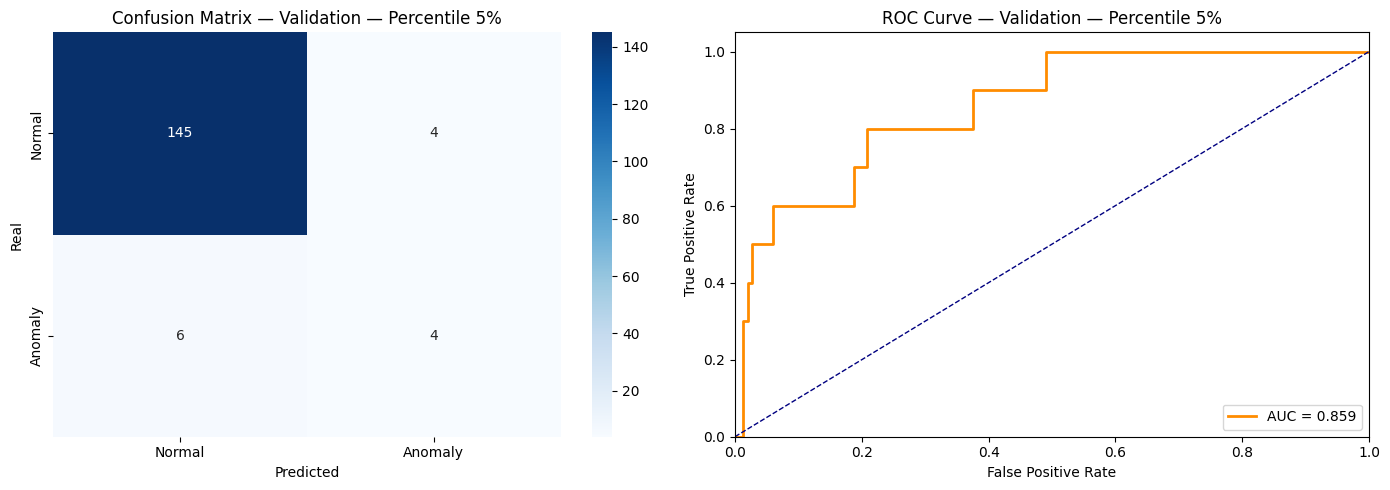


 Test — Percentile 5%
Precision: 0.5652
Recall: 0.4483
F2 Score: 0.4676

              precision    recall  f1-score   support

      Normal       0.88      0.92      0.90       130
     Anomaly       0.57      0.45      0.50        29

    accuracy                           0.84       159
   macro avg       0.72      0.69      0.70       159
weighted avg       0.82      0.84      0.83       159



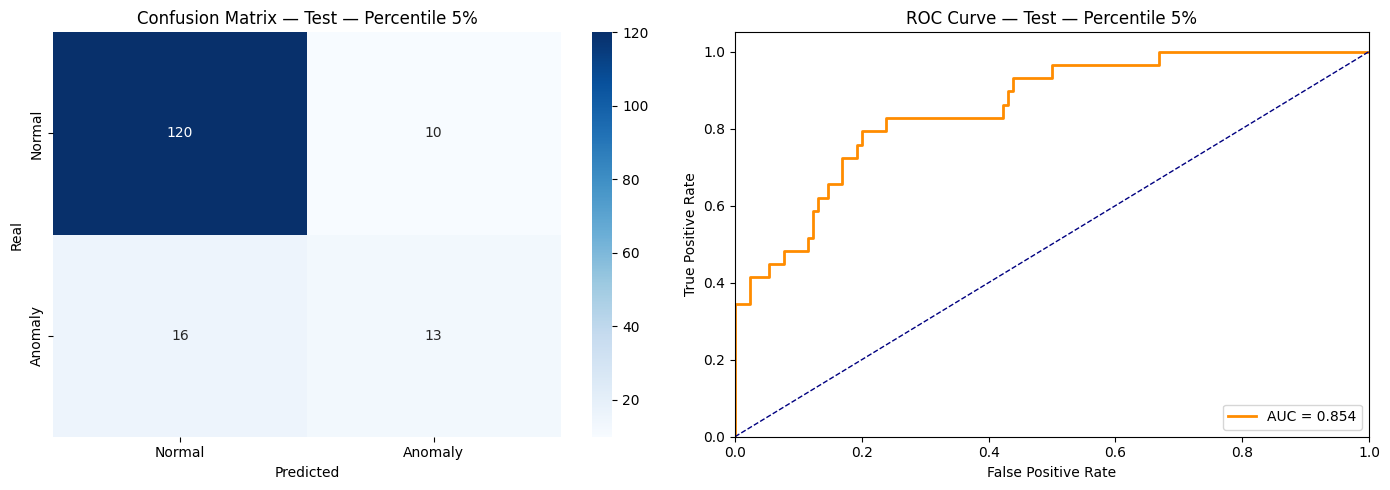

In [139]:
iso_pct, threshold_pct, sv_pct, st_pct, str_pct, yv_pct, yt_pct = \
    run_isolation_forest_percentile(
        X_train_scaled, X_train_full_scaled, X_val_scaled, X_test_scaled,
        X_train_full, X_val, X_test,
        score_percentile=5.0
    )

p_val, r_val, f2_val, auc_val = evaluate_model(
    y_val, yv_pct, sv_pct, "Validation", method_label="Percentile 5%"
)
p_test, r_test, f2_test, auc_test = evaluate_model(
    y_test, yt_pct, st_pct, "Test", method_label="Percentile 5%"
)

Now, we test several hyperparamters on the validation and choose the one that maximizes a metric, for example the F2-score, which gives more importance to recall.

In [140]:
def tune_isolation_forest(
    X_train_scaled,
    X_val_scaled,
    y_val,
    percentile_grid=np.arange(1.0, 35.5, 0.5),
    beta=2.0,
    random_state=42
):
    results = []

    param_grid = {
        "n_estimators": [300, 600, 1000],
        "max_samples": ["auto", 128, 256, 512],
        "max_features": [0.5, 0.7, 1.0],
    }

    for n_estimators in param_grid["n_estimators"]:
        for max_samples in param_grid["max_samples"]:
            for max_features in param_grid["max_features"]:

                iso = IsolationForest(
                    n_estimators=n_estimators,
                    max_samples=max_samples,
                    max_features=max_features,
                    contamination="auto",
                    random_state=random_state,
                    n_jobs=-1
                )

                iso.fit(X_train_scaled)

                scores_val = iso.decision_function(X_val_scaled)
                auc = roc_auc_score(y_val, -scores_val)

                for percentile in percentile_grid:
                    threshold = np.percentile(scores_val, percentile)
                    y_pred_val = (scores_val <= threshold).astype(int)

                    precision = precision_score(y_val, y_pred_val, zero_division=0)
                    recall = recall_score(y_val, y_pred_val, zero_division=0)
                    fbeta = fbeta_score(y_val, y_pred_val, beta=beta, zero_division=0)

                    results.append({
                        "n_estimators": n_estimators,
                        "max_samples": max_samples,
                        "max_features": max_features,
                        "percentile": percentile,
                        "threshold": threshold,
                        "precision": precision,
                        "recall": recall,
                        f"f{beta}": fbeta,
                        "roc_auc": auc,
                        "n_alerts_val": y_pred_val.sum()
                    })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by=[f"f{beta}", "recall", "precision"],
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [141]:
tuning_results = tune_isolation_forest(
    X_train_scaled,
    X_val_scaled,
    y_val.values,
    percentile_grid=np.arange(1.0, 35.5, 0.5),
    beta=2.0,
    random_state=RANDOM_STATE
)

tuning_results.head(10)

,n_estimators,max_samples,max_features,percentile,threshold,precision,recall,f2.0,roc_auc,n_alerts_val
0,300,128,1.0,6.5,0.011121,0.545455,0.6,0.588235,0.888591,11
1,300,128,1.0,7.0,0.014973,0.500000,0.6,0.576923,0.888591,12
2,300,128,1.0,7.5,0.015048,0.500000,0.6,0.576923,0.888591,12
3,600,128,1.0,7.0,0.015947,0.500000,0.6,0.576923,0.869128,12
4,600,128,1.0,7.5,0.016071,0.500000,0.6,0.576923,0.869128,12
5,300,auto,0.7,13.0,0.040188,0.333333,0.7,0.573770,0.864430,21
6,300,256,0.7,13.0,0.040188,0.333333,0.7,0.573770,0.864430,21
7,300,128,1.0,8.0,0.015660,0.461538,0.6,0.566038,0.888591,13
8,600,128,1.0,8.0,0.017255,0.461538,0.6,0.566038,0.869128,13
9,1000,128,1.0,8.0,0.015473,0.461538,0.6,0.566038,0.851007,13


In [142]:
best = tuning_results.iloc[0]

iso_opt = IsolationForest(
    n_estimators=int(best["n_estimators"]),
    max_samples=best["max_samples"],
    max_features=best["max_features"],
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the optimized model on normal training observations
iso_opt.fit(X_train_scaled)

# Compute anomaly scores
scores_val_opt = iso_opt.decision_function(X_val_scaled)
scores_test_opt = iso_opt.decision_function(X_test_scaled)

# Store scores as pandas Series
sv_opt = pd.Series(
    scores_val_opt,
    index=X_val.index,
    name="AnomalyScore"
)

st_opt = pd.Series(
    scores_test_opt,
    index=X_test.index,
    name="AnomalyScore"
)

# Use the best threshold selected on validation
threshold_opt = best["threshold"]

# Convert scores into binary predictions
yv_opt = (scores_val_opt <= threshold_opt).astype(int)
yt_opt = (scores_test_opt <= threshold_opt).astype(int)

print("Best optimized Isolation Forest configuration:")
print(best)

print("\nOptimized threshold:")
print(f"{threshold_opt:.6f}")

print("\nValidation predictions:")
print(f"{yv_opt.sum()} anomalies / {len(yv_opt)} weeks")

print("\nTest predictions:")
print(f"{yt_opt.sum()} anomalies / {len(yt_opt)} weeks")

Best optimized Isolation Forest configuration:
n_estimators         300
max_samples          128
max_features         1.0
percentile           6.5
threshold       0.011121
precision       0.545455
recall               0.6
f2.0            0.588235
roc_auc         0.888591
n_alerts_val          11
Name: 0, dtype: object

Optimized threshold:
0.011121

Validation predictions:
11 anomalies / 159 weeks

Test predictions:
21 anomalies / 159 weeks



 Validation — Optimized Isolation Forest
Precision: 0.5455
Recall: 0.6000
F2 Score: 0.5882

              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       149
     Anomaly       0.55      0.60      0.57        10

    accuracy                           0.94       159
   macro avg       0.76      0.78      0.77       159
weighted avg       0.95      0.94      0.94       159



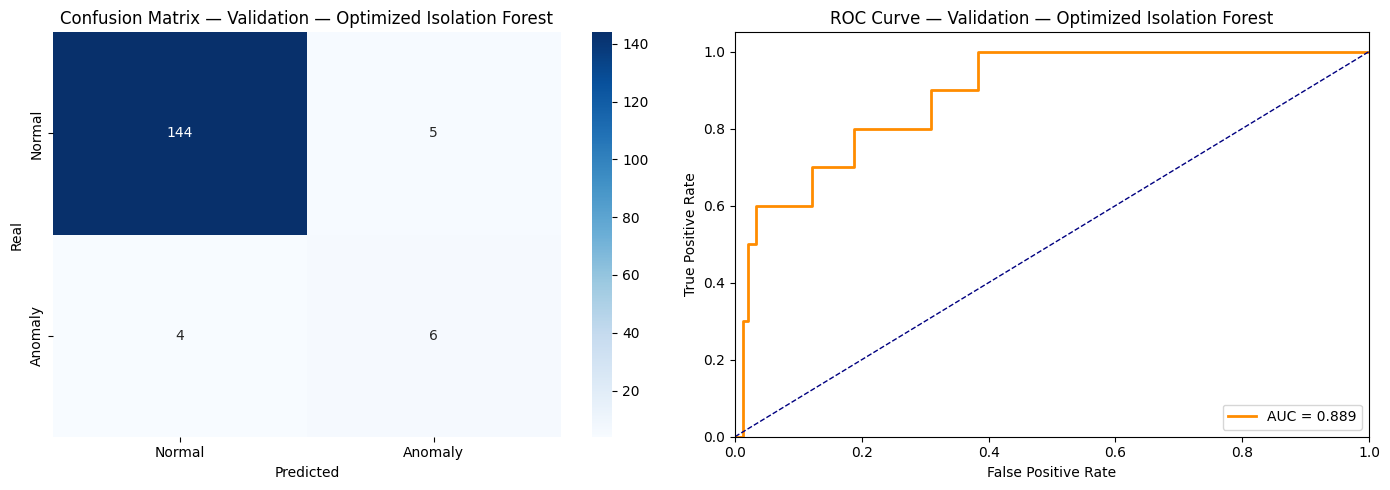


 Test — Optimized Isolation Forest
Precision: 0.5714
Recall: 0.4138
F2 Score: 0.4380

              precision    recall  f1-score   support

      Normal       0.88      0.93      0.90       130
     Anomaly       0.57      0.41      0.48        29

    accuracy                           0.84       159
   macro avg       0.72      0.67      0.69       159
weighted avg       0.82      0.84      0.83       159



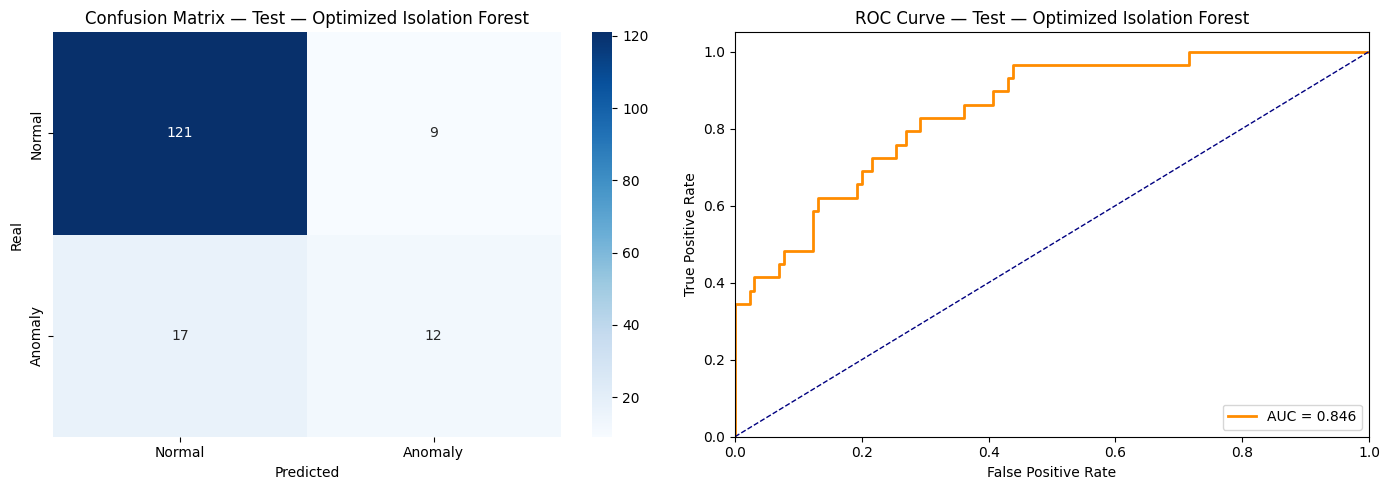

In [143]:
p_val_opt, r_val_opt, f1_val_opt, auc_val_opt = evaluate_model(
    y_val,
    yv_opt,
    sv_opt,
    "Validation",
    method_label="Optimized Isolation Forest"
)

p_test_opt, r_test_opt, f1_test_opt, auc_test_opt = evaluate_model(
    y_test,
    yt_opt,
    st_opt,
    "Test",
    method_label="Optimized Isolation Forest"
)

After hyperparameter tuning, the optimized Isolation Forest shows a stronger performance on the validation set, with a recall of 0.60 and an F2-score of 0.588. This confirms that the selected configuration improves the model’s ability to detect crisis periods on the validation sample. The validation ROC-AUC is also high, at 0.889, suggesting that the model ranks abnormal observations relatively well.

On the test set, the model remains reasonably robust, with a ROC-AUC of 0.846 and a precision of 0.571 for anomaly detection. However, recall decreases to 0.414, meaning that the model still misses a significant number of crisis observations. Compared with the validation set, this drop suggests that some crisis periods in the test set are harder to distinguish from normal market conditions.

Overall, the optimized Isolation Forest improves the precision of crisis alerts and maintains a good global ranking ability, but the recall remains limited on unseen data. This highlights the main trade-off of the Early Warning System: reducing false alarms improves precision, but it can also lead to more missed crises.

## 8. Temporal Visualization of the Anomaly Score

The anomaly score is visualized over time, superimposed on the actual labels

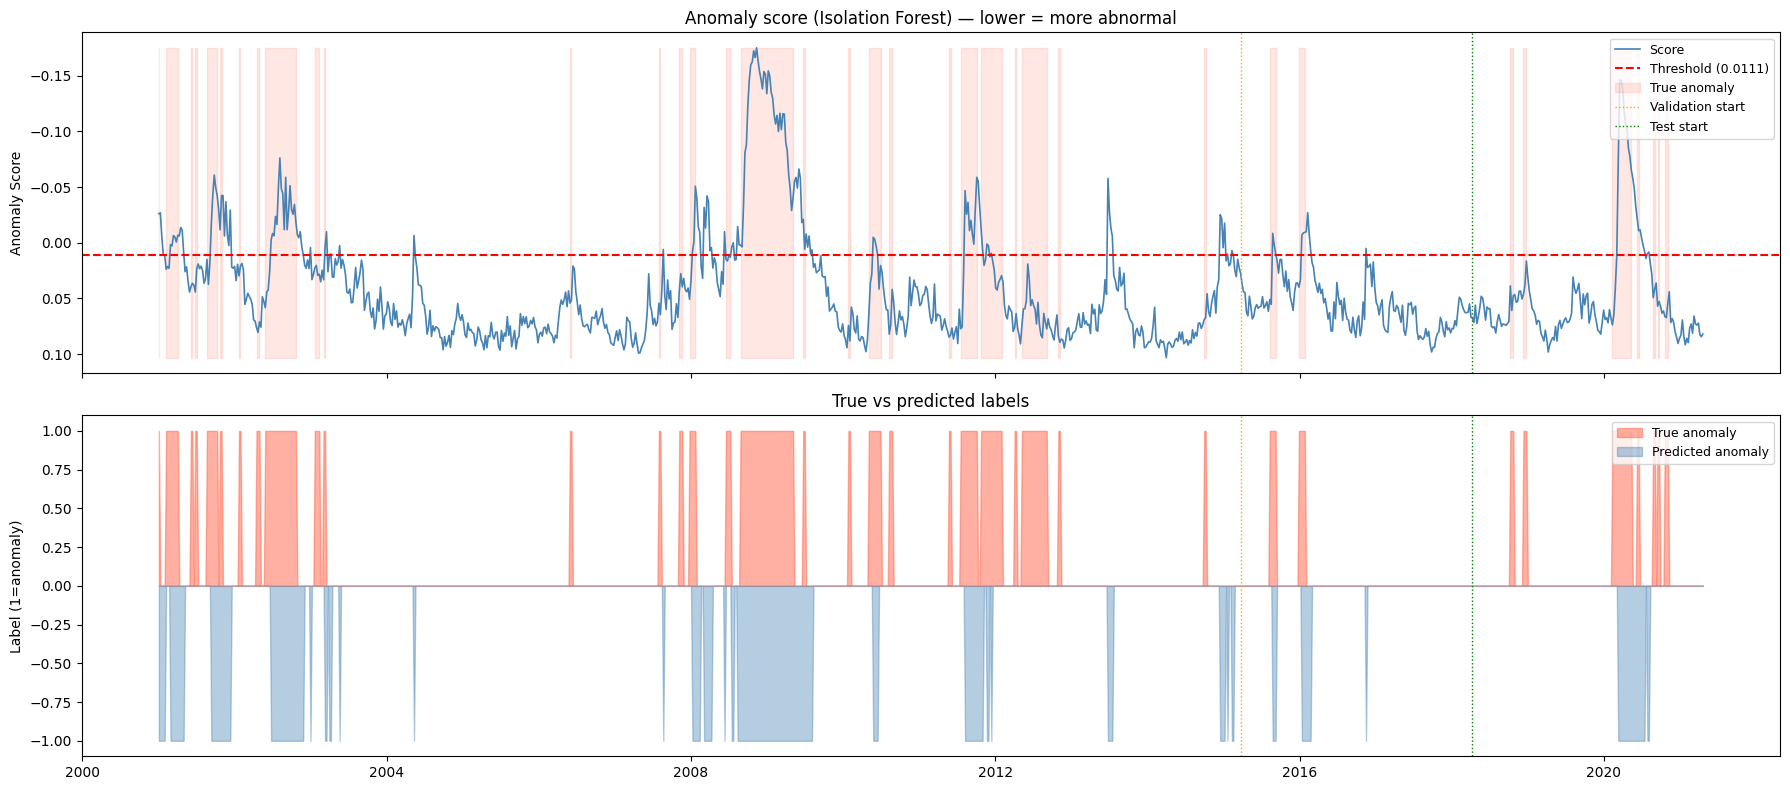

In [144]:
# Scores on the full dataset (train + validation + test)
all_features_scaled = scaler.transform(returns_df[feature_cols])
scores_all = iso_opt.decision_function(all_features_scaled)
scores_all_s = pd.Series(scores_all, index=returns_df.index, name="AnomalyScore")

# Active threshold (optimized method)
active_threshold = threshold_opt

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# — Anomaly score —
axes[0].plot(scores_all_s.index, scores_all_s.values, color="steelblue", lw=1.2, label="Score")
axes[0].axhline(active_threshold, color="red", lw=1.5, linestyle="--",
                label=f"Threshold ({active_threshold:.4f})")
axes[0].fill_between(
    returns_df.index,
    scores_all_s.min(), scores_all_s.max(),
    where=(returns_df[LABEL_COL] == 1),
    alpha=0.15, color="tomato", label="True anomaly"
)
axes[0].axvline(df_val.index[0],  color="orange", lw=1, linestyle=":", label="Validation start")
axes[0].axvline(df_test.index[0], color="green",  lw=1, linestyle=":", label="Test start")
axes[0].set_ylabel("Anomaly Score")
axes[0].set_title("Anomaly score (Isolation Forest) — lower = more abnormal")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].invert_yaxis()

# True vs predicted labels
y_pred_all = (scores_all <= active_threshold).astype(int)
y_pred_all_s = pd.Series(y_pred_all, index=returns_df.index)

axes[1].fill_between(returns_df.index, returns_df[LABEL_COL].values,
                     alpha=0.5, color="tomato", label="True anomaly")
axes[1].fill_between(returns_df.index, -y_pred_all_s.values,
                     alpha=0.4, color="steelblue", label="Predicted anomaly")
axes[1].axvline(df_val.index[0],  color="orange", lw=1, linestyle=":")
axes[1].axvline(df_test.index[0], color="green",  lw=1, linestyle=":")
axes[1].set_ylabel("Label (1=anomaly)")
axes[1].set_title("True vs predicted labels")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# 9. PCA Projection

Test data is projected in 2D using PCA to visualize the separation between normal and abnormal values. Four categories are distinguished: True Positive, True Negative, False Positive, and False Negative.

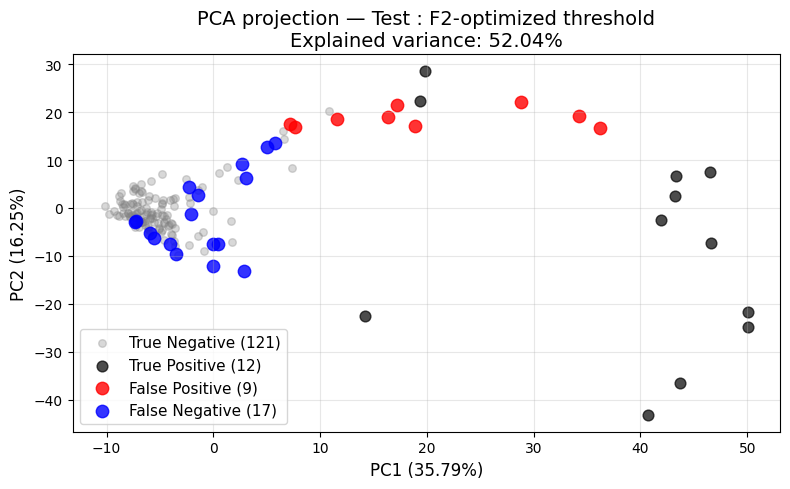

In [145]:
def plot_pca_results(X_scaled, y_true, y_pred, split_name):

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)

    categories = np.where(
        (y_true_arr == 0) & (y_pred_arr == 0), "True Negative",
        np.where(
            (y_true_arr == 1) & (y_pred_arr == 1), "True Positive",
            np.where(
                (y_true_arr == 0) & (y_pred_arr == 1), "False Positive",
                "False Negative"
            )
        )
    )

    pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Category": categories})

    color_map = {
        "True Negative" : ("gray",  0.3, 30),
        "True Positive" : ("black", 0.7, 60),
        "False Positive": ("red",   0.8, 80),
        "False Negative": ("blue",  0.8, 80),
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    for cat, (color, alpha, size) in color_map.items():
        mask = pca_df["Category"] == cat
        if mask.sum() > 0:
            ax.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
                       c=color, alpha=alpha, s=size, label=f"{cat} ({mask.sum()})")

    ax.set_title(f"PCA projection — {split_name}\nExplained variance: {explained.sum():.2%}", fontsize=14)
    ax.set_xlabel(f"PC1 ({explained[0]:.2%})", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained[1]:.2%})", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Use the optimized model and its test predictions
plot_pca_results(X_test_scaled, y_test.values, yt_opt, "Test : F2-optimized threshold")

The PCA projection provides a visual interpretation of the model’s results on the test set. True negatives are mostly concentrated in a compact region, suggesting that normal periods share similar feature patterns. True positives are generally farther away from this normal cluster, which explains why the model detects them as anomalies. False positives appear in intermediate regions, meaning that some normal periods look similar to crisis periods. False negatives are close to the normal cluster, which explains why these crises are harder to detect. Overall, the graph shows that the model captures part of the abnormal market structure, although some crisis periods remain difficult to distinguish from normal conditions.


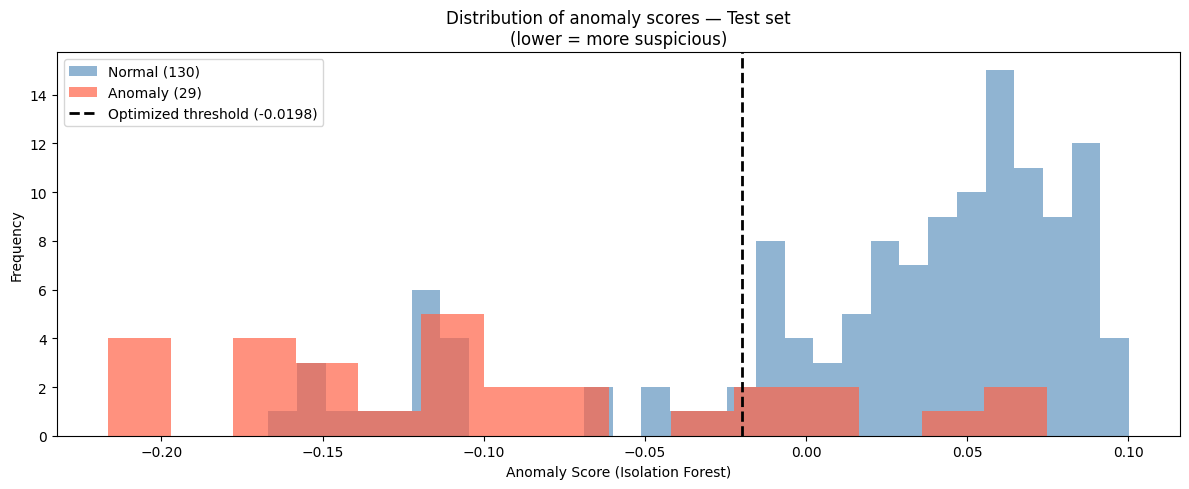

In [163]:
# Score distribution by true label (test set)
scores_test_opt = st_opt.values  # test scores from the optimized model

fig, ax = plt.subplots(figsize=(12, 5))

scores_normal = scores_test_opt[y_test.values == 0]
scores_anomaly = scores_test_opt[y_test.values == 1]

ax.hist(
    scores_normal,
    bins=30,
    alpha=0.6,
    color="steelblue",
    label=f"Normal ({len(scores_normal)})"
)

ax.hist(
    scores_anomaly,
    bins=15,
    alpha=0.7,
    color="tomato",
    label=f"Anomaly ({len(scores_anomaly)})"
)

ax.axvline(
    threshold_opt,
    color="black",
    lw=2,
    linestyle="--",
    label=f"Optimized threshold ({threshold_opt:.4f})"
)

ax.set_xlabel("Anomaly Score (Isolation Forest)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of anomaly scores — Test set\n(lower = more suspicious)")
ax.legend()

plt.tight_layout()
plt.show()

The score distribution shows that most normal observations receive high anomaly scores, while many crisis periods receive lower scores and are therefore detected by the model. However, the two distributions still overlap: some normal periods are classified as false alarms, and some crisis periods remain too close to normal conditions to be detected. Overall, the model captures a meaningful anomaly signal, but the separation between normal and crisis periods is not perfect.

## 10. Feature Importance

Isolation Forest does not provide native feature importance scores, unlike supervised tree-based models such as Random Forest. To interpret the model, we therefore use permutation importance.

The idea is to randomly shuffle one feature at a time while keeping all other features unchanged, and then measure how much the model performance deteriorates. In this notebook, the performance drop is evaluated using the ROC-AUC score. If permuting a feature leads to a strong decrease in ROC-AUC, this means that the feature contains useful information for distinguishing normal market periods from crisis periods.

From a financial perspective, the most important features can be interpreted as the most discriminant market signals. They are the variables that contribute the most to separating normal regimes from periods of financial stress.


In [148]:
def permutation_importance_manual(iso_model, X, y, feature_names, n_repeats=20, random_state=42):

    rng = np.random.default_rng(random_state)
    
    # Baseline score without permutation
    base_scores = iso_model.decision_function(X)
    base_auc = roc_auc_score(y, -base_scores)
    
    importances = np.zeros((len(feature_names), n_repeats))
    
    for i, col in enumerate(feature_names):
        for r in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, i] = rng.permutation(X_permuted[:, i])
            
            permuted_scores = iso_model.decision_function(X_permuted)
            permuted_auc = roc_auc_score(y, -permuted_scores)
            
            # Performance drop = feature importance
            importances[i, r] = base_auc - permuted_auc
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances.mean(axis=1),
        "Std": importances.std(axis=1)
    }).sort_values("Importance", ascending=False)
    
    print(f"Baseline ROC-AUC: {base_auc:.4f}")
    return importance_df


print("Computing permutation importance (this may take a few seconds)...")

importance_df = permutation_importance_manual(
    iso_opt,
    X_test_scaled,
    y_test.values,
    feature_cols,
    n_repeats=20,
    random_state=RANDOM_STATE
)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

Computing permutation importance (this may take a few seconds)...
Baseline ROC-AUC: 0.8456

Top 15 most important features:
               Feature  Importance      Std
      Cl1_drawdown_52w    0.011565 0.003814
        VIX_change_12w    0.011167 0.004127
          BDIY_vol_26w    0.008966 0.002889
              ECSURPUS    0.007533 0.002469
           BDIY_vol_4w    0.006950 0.003537
     MXBR_drawdown_52w    0.005663 0.002557
           Cl1_vol_26w    0.005252 0.002969
     GBP_corr_MXUS_26w    0.004735 0.003122
           MXBR_vol_4w    0.004496 0.001829
           MXIN_mom_4w    0.004072 0.002089
                  MXEU    0.003979 0.001071
           MXUS_vol_4w    0.003873 0.001451
          MXUS_vol_12w    0.003846 0.002215
          BDIY_vol_12w    0.003700 0.001738
LUACTRUU_corr_MXUS_26w    0.003607 0.002965


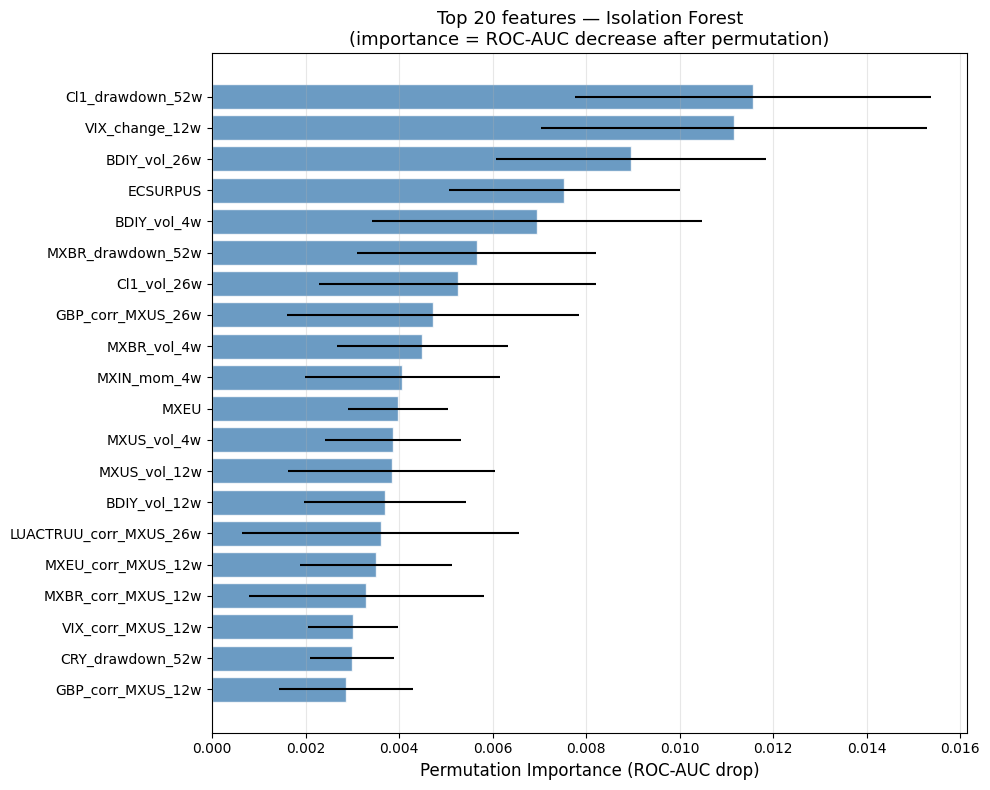

In [149]:
# Visualization — Top 20 features
top_n = 20
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_df["Feature"][::-1],
    top_df["Importance"][::-1],
    xerr=top_df["Std"][::-1],
    color="steelblue", alpha=0.8, edgecolor="white"
)

ax.set_xlabel("Permutation Importance (ROC-AUC drop)", fontsize=12)
ax.set_title(
    f"Top {top_n} features — Isolation Forest\n"
    "(importance = ROC-AUC decrease after permutation)",
    fontsize=13
)

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

The model does not rely on absurd variables. It identifies classic crisis signals: increased volatility, stress on the VIX, significant drawdowns, changes in correlations between markets.

## Analysis of undetected crises

In [150]:
false_negative_dates = X_test.index[(y_test.values == 1) & (yt_opt == 0)]
false_positive_dates = X_test.index[(y_test.values == 0) & (yt_opt == 1)]

print("False negatives:")
print(false_negative_dates)

print("\nFalse positives:")
print(false_positive_dates)

False negatives:
DatetimeIndex(['2018-10-09', '2018-10-16', '2018-10-23', '2018-12-11',
               '2018-12-18', '2018-12-25', '2020-02-11', '2020-02-18',
               '2020-02-25', '2020-03-03', '2020-08-25', '2020-09-01',
               '2020-09-15', '2020-09-22', '2020-10-20', '2020-10-27',
               '2020-11-03'],
              dtype='datetime64[ns]', name='Date', freq=None)

False positives:
DatetimeIndex(['2020-05-19', '2020-05-26', '2020-06-02', '2020-06-23',
               '2020-06-30', '2020-07-07', '2020-07-14', '2020-07-28',
               '2020-08-04'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [151]:
returns_df.loc[false_negative_dates, feature_cols].describe().T.sort_values("mean", ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
VIX_change_12w,17.0,6.540000,8.380398,-5.780000,2.320000,5.210000,11.520000,24.020000
VIX_change_4w,17.0,5.785294,5.922252,-3.410000,2.490000,4.080000,7.080000,20.770000
LF98TRUU_corr_MXUS_26w,17.0,0.714220,0.114088,0.475891,0.626069,0.718594,0.798047,0.881786
MXEU_corr_MXUS_26w,17.0,0.712890,0.141998,0.491186,0.593490,0.746402,0.809401,0.938805
LF98TRUU_corr_MXUS_12w,17.0,0.673973,0.157170,0.408429,0.549075,0.723451,0.801523,0.882746
MXCN_corr_MXUS_12w,17.0,0.662132,0.125239,0.420356,0.568281,0.635335,0.765359,0.864669
LP01TREU_corr_MXUS_26w,17.0,0.644904,0.151769,0.435898,0.516127,0.615144,0.751381,0.934146
MXEU_corr_MXUS_12w,17.0,0.639656,0.238835,0.247135,0.451903,0.594565,0.824347,0.963329
LG30TRUU_corr_MXUS_26w,17.0,0.630256,0.123397,0.426025,0.558906,0.612142,0.692382,0.875199
MXJP_corr_MXUS_26w,17.0,0.618554,0.137902,0.413050,0.478066,0.629497,0.726595,0.827362


The model's errors are also interpretable: false positives appear mainly after the COVID crisis, which may correspond to unlabeled residual stress, while false negatives correspond to less extreme crisis periods or periods closer to the normal regime.

In [161]:
def evaluate_top_features(
    importance_df,
    feature_cols,
    X_train_full,
    y_train_full,
    X_val,
    y_val,
    X_test,
    y_test,
    scaler_class,
    top_k_list=[10, 15, 20, 30, 40, 60],
    beta=2.0,
    random_state=42
):
    results = []

    for top_k in top_k_list:
        selected_features = importance_df.head(top_k)["Feature"].tolist()

        X_train_full_k = X_train_full[selected_features]
        X_val_k = X_val[selected_features]
        X_test_k = X_test[selected_features]

        X_train_normal_k = X_train_full_k[y_train_full == 0]

        scaler_k = scaler_class()
        X_train_scaled_k = scaler_k.fit_transform(X_train_normal_k)
        X_val_scaled_k = scaler_k.transform(X_val_k)
        X_test_scaled_k = scaler_k.transform(X_test_k)

        tuning_k = tune_isolation_forest(
            X_train_scaled_k,
            X_val_scaled_k,
            y_val.values if hasattr(y_val, "values") else y_val,
            percentile_grid=np.arange(1.0, 35.5, 0.5),
            beta=beta,
            random_state=random_state
        )

        best_k = tuning_k.iloc[0]

        # Convert parameters stored in the results DataFrame
        best_max_samples = best_k["max_samples"]

        if best_max_samples != "auto":
            best_max_samples = int(best_max_samples)

        best_max_features = float(best_k["max_features"])

        iso_k = IsolationForest(
            n_estimators=int(best_k["n_estimators"]),
            max_samples=best_max_samples,
            max_features=best_max_features,
            contamination="auto",
            random_state=random_state,
            n_jobs=-1
        )

        iso_k.fit(X_train_scaled_k)

        test_scores_k = iso_k.decision_function(X_test_scaled_k)
        y_pred_test_k = (test_scores_k <= best_k["threshold"]).astype(int)

        results.append({
            "top_k": top_k,
            "n_estimators": int(best_k["n_estimators"]),
            "max_samples": best_max_samples,
            "max_features": best_max_features,
            "percentile": best_k["percentile"],
            "threshold": best_k["threshold"],
            "test_precision": precision_score(y_test, y_pred_test_k, zero_division=0),
            "test_recall": recall_score(y_test, y_pred_test_k, zero_division=0),
            "test_f2": fbeta_score(y_test, y_pred_test_k, beta=beta, zero_division=0),
            "test_auc": roc_auc_score(y_test, -test_scores_k)
        })

    return pd.DataFrame(results).sort_values("test_f2", ascending=False).reset_index(drop=True)

In [162]:
top_feature_results = evaluate_top_features(
    importance_df=importance_df,
    feature_cols=feature_cols,
    X_train_full=X_train_full,
    y_train_full=y_train_full,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    scaler_class=StandardScaler,
    top_k_list=[10, 15, 20, 30, 40, 60],
    beta=2.0,
    random_state=RANDOM_STATE
)

top_feature_results

,top_k,n_estimators,max_samples,max_features,percentile,threshold,test_precision,test_recall,test_f2,test_auc
0,15,1000,512,0.7,17.5,-0.019845,0.468085,0.758621,0.674847,0.843767
1,20,300,512,0.7,9.5,-0.038178,0.525000,0.724138,0.673077,0.882759
2,30,300,128,1.0,13.0,-0.024036,0.525000,0.724138,0.673077,0.901857
3,10,300,512,1.0,11.0,-0.079303,0.527778,0.655172,0.625000,0.848806
4,40,300,128,1.0,4.5,-0.035523,0.527778,0.655172,0.625000,0.885942
5,60,600,512,1.0,4.0,-0.042426,0.551724,0.551724,0.551724,0.914589


In [164]:
# Refit the best Isolation Forest
iso_topk = IsolationForest(
    n_estimators=int(best_topk["n_estimators"]),
    max_samples=best_max_samples,
    max_features=best_max_features,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_topk.fit(X_train_scaled_topk)

# Compute anomaly scores
scores_val_topk = iso_topk.decision_function(X_val_scaled_topk)
scores_test_topk = iso_topk.decision_function(X_test_scaled_topk)

# Store scores as pandas Series
sv_opt = pd.Series(
    scores_val_topk,
    index=X_val.index,
    name="AnomalyScore"
)

st_opt = pd.Series(
    scores_test_topk,
    index=X_test.index,
    name="AnomalyScore"
)

# Use the threshold selected during validation tuning
threshold_opt = best_topk["threshold"]

# Convert scores into binary predictions
yv_opt = (scores_val_topk <= threshold_opt).astype(int)
yt_opt = (scores_test_topk <= threshold_opt).astype(int)


 Validation — Optimized Top-K Isolation Forest
Precision: 0.2857
Recall: 0.8000
F2 Score: 0.5882

              precision    recall  f1-score   support

      Normal       0.98      0.87      0.92       149
     Anomaly       0.29      0.80      0.42        10

    accuracy                           0.86       159
   macro avg       0.64      0.83      0.67       159
weighted avg       0.94      0.86      0.89       159



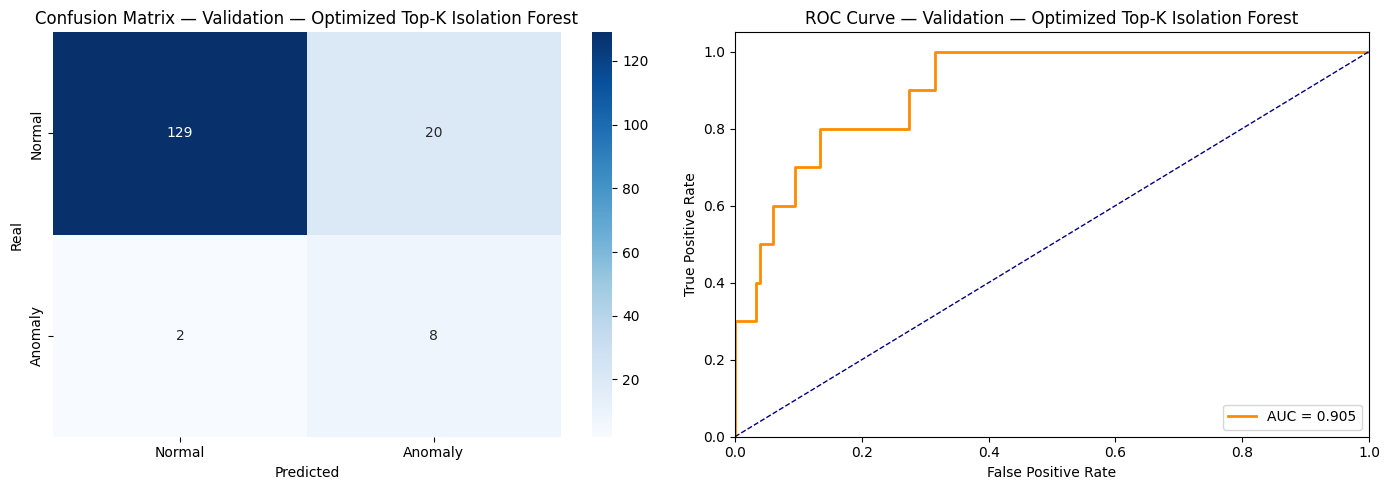


 Test — Optimized Top-K Isolation Forest
Precision: 0.4681
Recall: 0.7586
F2 Score: 0.6748

              precision    recall  f1-score   support

      Normal       0.94      0.81      0.87       130
     Anomaly       0.47      0.76      0.58        29

    accuracy                           0.80       159
   macro avg       0.70      0.78      0.72       159
weighted avg       0.85      0.80      0.82       159



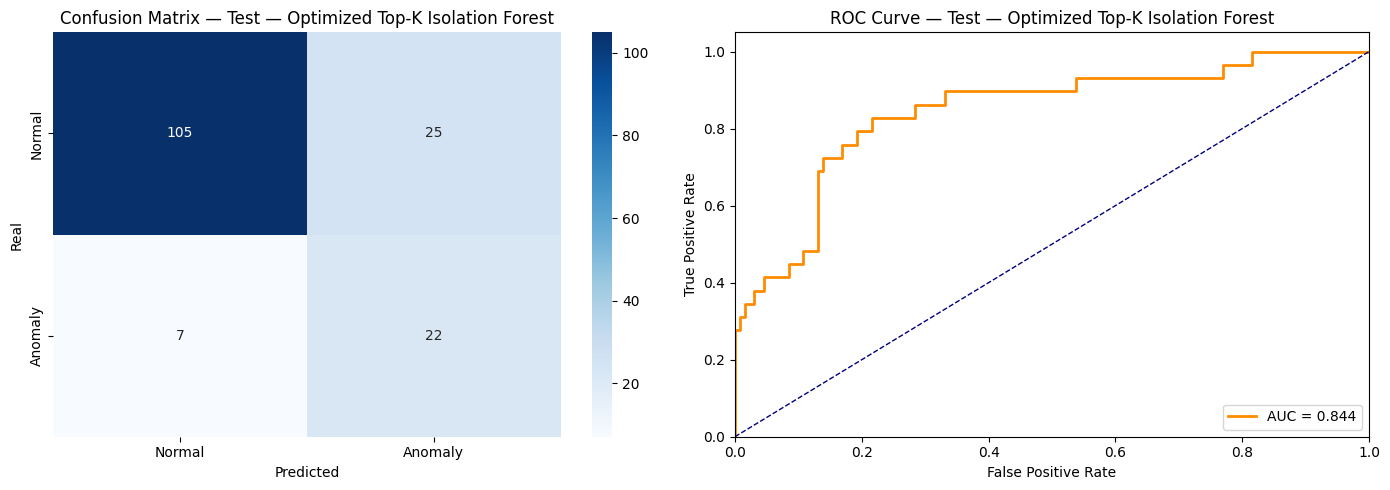

In [165]:
p_val_opt, r_val_opt, f1_val_opt, auc_val_opt = evaluate_model(
    y_val,
    yv_opt,
    sv_opt,
    "Validation",
    method_label="Optimized Top-K Isolation Forest"
)

p_test_opt, r_test_opt, f1_test_opt, auc_test_opt = evaluate_model(
    y_test,
    yt_opt,
    st_opt,
    "Test",
    method_label="Optimized Top-K Isolation Forest"
)

The optimized Top-K Isolation Forest performs very well on the validation set, especially in terms of recall and ROC-AUC. However, performance decreases on the test set, which suggests that the model does not fully generalize to unseen market regimes. This is expected in financial crisis detection, since market dynamics are non-stationary and crisis patterns can differ across periods. The model remains able to detect a large proportion of test anomalies, but it also produces more false positives, indicating a more aggressive alerting behavior. Overall, the results show that Top-K feature selection improves crisis detection on the valiµdation set, but the gap with the test set highlights the risk of overfitting the validation period and the difficulty of building a stable Early Warning System across changing market conditions.